# 1교시: ReAct의 한계와 에이전트 루프 개선

## 학습 목표
1. **LangGraph StateGraph**로 에이전트 루프를 명시적으로 구성하고 투명하게 관찰할 수 있습니다.
2. **`create_agent`** 를 활용해 동일한 에이전트를 간편 생성하며, 내부적으로 LangGraph 런타임이 동작함을 이해합니다.
3. **middleware**를 이용하여 에이전트에 하네스 기능(권한 게이트, 로깅)을 주입하는 방법을 체득합니다.
4. **AgentTracer**로 루프 내 단계별 동작(지연시간, 토큰 사용량)을 추적하고 시각화할 수 있습니다.

--- 
ReAct 에이전트는 사용자의 질문을 해결하기 위해 **생각(Thought) ➔ 행동(Action) ➔ 관찰(Observation)** 의 주기를 반복하며 자율적으로 의사를 결정하는 대표적인 에이전트 아키텍처입니다.

#### 💡 핵심 개념 요약
- **Thought (사고)**: 현재 상황에서 무엇을 해야 하는지, 어떤 도구(Tool)가 필요한지 LLM이 스스로 추론합니다.
- **Action (행동)**: 추론한 결과를 바탕으로 매개변수를 생성하여 도구(Tool)를 직접 실행(호출)합니다.
- **Observation (관찰)**: 도구의 실행 결과값을 확인하여 컨텍스트에 갱신하고 다음 행동을 결정합니다.

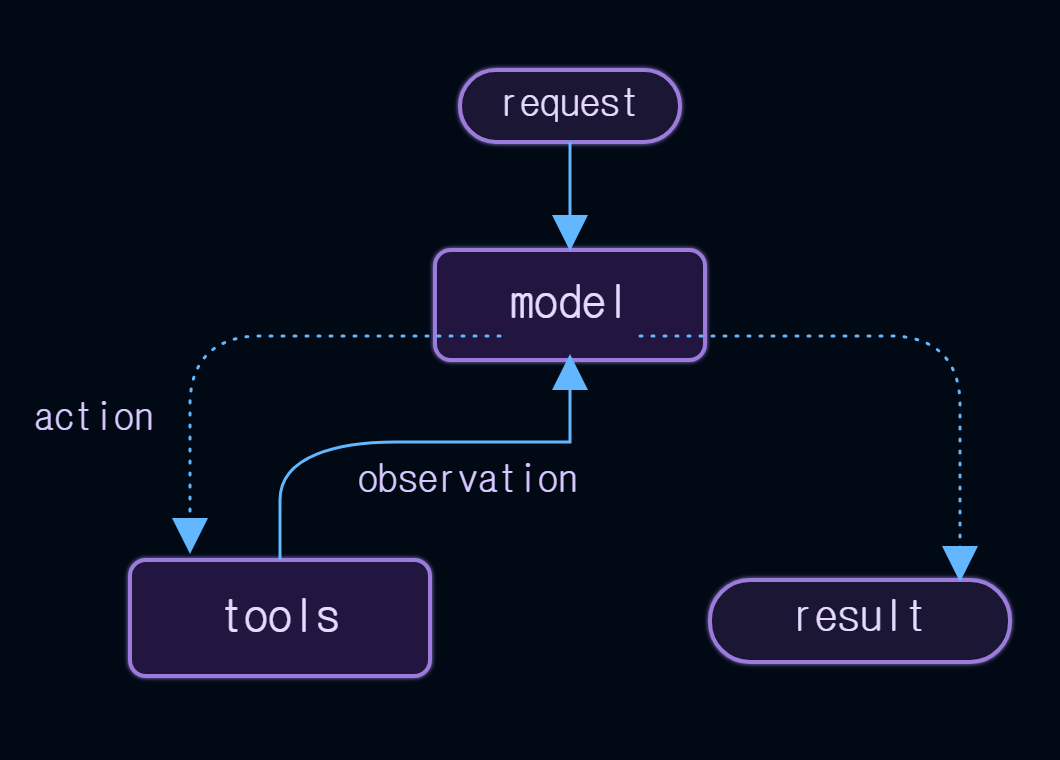

---
## ⚙️ 환경 설정 (Setup)

필요한 라이브러리를 임포트하고 에이전트에 주입할 API 설정 및 기본 도구들을 선언합니다.

In [ ]:
import os
import warnings
import langchain_core
warnings.filterwarnings("ignore")

from dotenv import load_dotenv, find_dotenv
from app.utils.llm import get_llm
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, ToolMessage

# .env 파일 로드 (부모 디렉토리를 포함해 자동 탐색)
load_dotenv(find_dotenv())

# 기본 LLM 선언
llm = get_llm("gemini-3.5-flash")
print("LLM initialized successfully!")

### 실습용 Mock 도구(Tools) 선언
- `search_file`: 파일 내용을 검색하는 가상 도구
- `calculator`: 수식을 연산하는 도구
- `delete_file`: 파일을 삭제하는 위험 도구

In [ ]:
@tool
def search_file(filename: str) -> str:
    """Search and retrieve the content of a file from the repository."""
    if filename == "paper.txt":
        return "연구 데이터 분석 결과: 최적 매개변수 x = 16 이며, 최종 평가는 수식 f(x) = 2 * x + 10 에 따라 산출된다."
    elif filename == "temp_logs.txt":
        return "[WARN] CPU usage high at 95%."
    return f"File '{filename}' not found."

@tool
def calculator(expr: str) -> str:
    """Calculate mathematical expressions. Input should be a python expression string like '2 * 16 + 10'."""
    try:
        cleaned = "".join(c for c in expr if c in "0123456789+-*/() ")
        val = eval(cleaned)
        return f"Result of '{expr}' is {val}"
    except Exception as e:
        return f"Calculation Error: {e}"

@tool
def delete_file(filename: str) -> str:
    """Delete a file from the disk. Warning: This is a destructive and dangerous operation."""
    return f"File '{filename}' has been permanently deleted."

tools = [search_file, calculator, delete_file]
tools_map = {t.name: t for t in tools}
print("Tools registered:", list(tools_map.keys()))

---
## 핵심 실습 1: StateGraph로 에이전트 루프 풀재현

LangGraph의 `StateGraph`와 `MessagesState`를 활용하여 에이전트 루프의 4단계를 명시적으로 기하 구조로 매핑합니다.
- **노드(Nodes)**: 
  1. `prompt_assemble`: 에이전트에 지시할 시스템 메시지 주입.
  2. `call_model`: 도구를 연계(bind_tools)한 LLM 호출.
  3. `execute_tools`: LLM 응답 내 tool_calls를 감지하여 도구 병렬 실행.

- **엣지(Edges)**:
  - `START` -> `prompt_assemble` -> `call_model`
  - `call_model` -> (도구 호출 여부에 따른 분기) -> `execute_tools` 또는 `end`
  - `execute_tools` -> `Tool 실행` -> `call_model` (재인퍼런스 루프)
  - `end` -> `END`

In [ ]:
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import RemoveMessage, BaseMessage

class AgentState(dict):
    messages: list[BaseMessage]

def prompt_assemble(state: AgentState):
    messages = state.get("messages", [])
    if messages and isinstance(messages[0], SystemMessage):
        return {"messages": messages}
        
    system_prompt = SystemMessage(
        content="You are a helpful research agent. Use tools when needed to retrieve or calculate answers."
    )
    
    remaining = [m for m in messages if not isinstance(m, SystemMessage)]
    return {"messages": [system_prompt] + remaining}

def call_model(state: AgentState):
    model_with_tools = llm.bind_tools(tools)
    response = model_with_tools.invoke(state["messages"])
    return {"messages": state["messages"] + [response]}

def execute_tools(state: AgentState):
    last_msg = state["messages"][-1]
    tool_messages = []
    if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
        for tool_call in last_msg.tool_calls:
            t_name = tool_call["name"]
            t_args = tool_call["args"]
            t_id = tool_call["id"]
            selected_tool = tools_map[t_name]
            result = selected_tool.invoke(t_args)
            tool_messages.append(ToolMessage(content=str(result), tool_call_id=t_id))
    return {"messages": state["messages"] + tool_messages}

def evaluate(state: AgentState):
    return state

def should_continue(state: AgentState):
    last_msg = state["messages"][-1]
    if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
        return "execute_tools"
    return "termination"

def build_agent_loop(llm, tools):
    graph = StateGraph(AgentState)
    
    graph.add_node("prompt_assemble", prompt_assemble)
    graph.add_node("call_model", call_model)
    graph.add_node("execute_tools", execute_tools)
    
    graph.add_edge(START, "prompt_assemble")
    graph.add_edge("prompt_assemble", "call_model")
    graph.add_conditional_edges(
        "call_model",
        should_continue,
        {
            "execute_tools": "execute_tools",
            "termination": END
        }
    )
    graph.add_edge("execute_tools", "call_model")
    
    return graph.compile()

custom_agent = build_agent_loop(llm, tools)
print("Custom Agent compiled successfully!")
custom_agent

직접 구현한 에이전트 루프 테스트

In [ ]:
from app.utils.message_utils import normalize_content

input_msg = {"messages": [HumanMessage(content="paper.txt 파일을 열고 그 수식에 x=5를 대입해서 계산해줘.")]}
result = custom_agent.invoke(input_msg)

final_answer = result["messages"][-1].content

# 최종 답변의 복잡한 content 구조를 깔끔한 문자열로 정규화
final_content = normalize_content(final_answer)

print("Final Answer:\n", final_content)

In [ ]:
for m in result["messages"]:
    m.pretty_print()

---
## 핵심 실습 2: create_agent 간편 생성 + LangGraph 런타임

매번 `StateGraph`를 구축하는 번거로움을 덜어주는 간편 빌더인 `create_agent`를 사용합니다.

In [ ]:
from langchain.agents import create_agent

# create_agent로 동일한 에이전트를 단 한 줄로 생성합니다.
langchain_agent = create_agent(model=llm, tools=tools)

In [ ]:
from app.utils.message_utils import normalize_content

input_msg = {"messages": [HumanMessage(content="paper.txt 파일을 열고 그 수식에 x=5를 대입해서 계산해줘.")]}
response = langchain_agent.invoke(input_msg)

final_answer = response["messages"][-1].content

# 최종 답변의 복잡한 content 구조를 깔끔한 문자열로 정규화
final_content = normalize_content(final_answer)

print("Final Answer:\n", final_content)

In [ ]:
for m in response["messages"]:
    m.pretty_print()

## 📊 에이전트 루프 아키텍처

에이전트 하네스(Harness)는 단순한 LLM API 호출 래퍼가 아닙니다. 아래와 같이 9대 중재 장치를 통해 비결정적인 인공지능을 엔터프라이즈 환경에 맞게 제어하는 에이전트 전용 운영체제(OS)의 역할을 수행합니다.

- **메모리 / 스킬 / 프로토콜**: 4계층 장기 기억 보존, ACI 스킬 셋 정의, 정보 불균형 해소
- **샌드박스 / LLM 엔진 / 추론 패턴**: 격리 환경 도구 실행, 하이브리드 모델 스위칭, Planning & Multi-agents
- **관측성 / 승인 게이트 / 가드레일**: 실행 궤적 실시간 모니터링, Allow/Ask/Deny 승인, 프롬프트 주입 차단

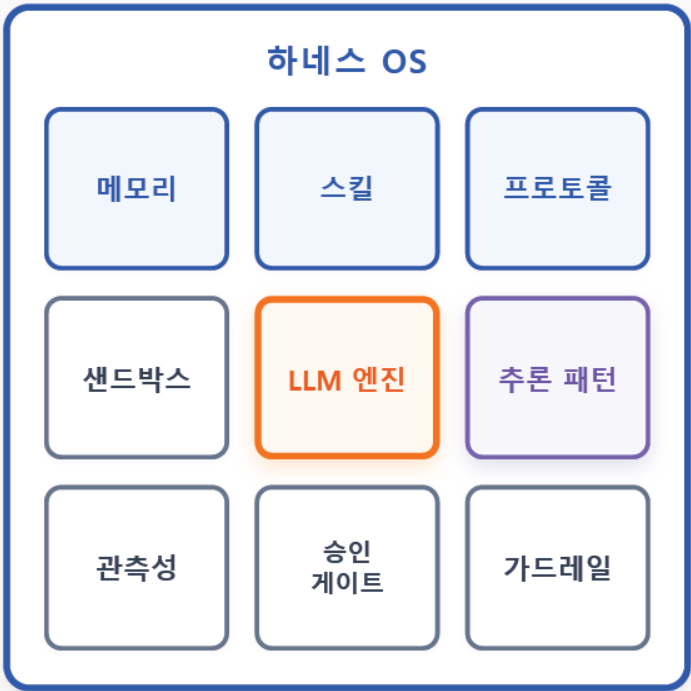

### 사례 연구 Claude Code `query Loop` 5단계 자율 순환 구조
Claude Code 가 매 턴 사용자 명령을 도구를 사용해 해결해 나가는 핵심 5단계 자율 순환 프로세스는 다음과 같습니다.
1. **1단계 - Message Preprocessing (컨텍스트 정화)**:
   - 과도한 토큰 소모와 프롬프트 한계 도달을 막기 위해 **Snip(오래된 도구 로그 잘라내기)**, **Micro/Auto-Compaction(대량 도구 출력 병합)** 및 **Collapse(비활성 텍스트 접기)**를 수행합니다.
2. **2단계 - API Streaming Call (모델 스트리밍 호출)**:
   - 5계층 정적/동적 프롬프트 스택, 가재된 대화 이력, 바인딩된 도구 스키마를 정합하여 LLM API를 스트리밍 형태로 호출합니다.
3. **3단계 - Error Withholding & Recovery (반응형 오류 복구)**:
   - API 통신 시 413 (Payload Too Large) 콘텍스트 오버플로우가 감지되면 하네스가 예외를 즉시 가로채고 **반응형 압축(Reactive Compaction)**을 자동 구동하여 루프를 중단 없이 복구합니다.
4. **4단계 - Tool Execution & Governance (도구 실행 및 거버넌스)**:
   - 도구 호출 명령 발생 시, 사용자가 사전에 정의한 **Allow/Ask/Deny 승인 게이트**를 통과시킵니다.
   - 안전 도구는 **최대 10개까지 병렬 비동기 실행**하고, 파일 쓰기 및 Bash 명령어 같은 위험 도구는 순차 실행합니다.
5. **5단계 - Post-processing & tool_use 검사**:
   - 추가 도구 호출 지시가 남아있다면 **1단계로 즉시 재진입**하여 루프를 돌고, 호출이 없다면 최종 답변을 전달하고 종료합니다.

In [ ]:
'''
Claude Code의 Agent Loop 슈도 코드

async def run_claude_query_loop(user_query: str):
    # 초기 컨텍스트 설정 (System Prompt + User Input)
    messages = [
        SystemMessage(content=STATIC_5LAYER_PROMPT), 
        HumanMessage(content=user_query)
    ]
    
    while True:
        #----------------------------------------------------------------------
        # [Step 1] Message Preprocessing (컨텍스트 정화 및 압축)
        #----------------------------------------------------------------------
        # - Snip: 이전 턴의 오래된 도구 실행 결과 로그를 잘라내어 캐시 세이브
        # - Compact: 도구 출력값의 메타데이터만 남기고 경량화
        compacted_messages = context_preprocessor.compact(messages)
        
        try:
            #----------------------------------------------------------------------
            # [Step 2] API Streaming Call (스트리밍 모델 호출)
            #----------------------------------------------------------------------
            stream = await llm.astream_call(
                messages=compacted_messages,
                tools=AVAILABLE_TOOLS_SCHEMA
            )
            llm_response = await stream.read_to_end()
            
        except APIError as error:
            #----------------------------------------------------------------------
            # [Step 3] Error Withholding & Recovery (반응형 자가 복구)
            #----------------------------------------------------------------------
            # 컨텍스트 오버플로우(413 Error) 발생 시 하네스가 가로채서 복구 시도
            if error.status_code == 413:
                # 즉각적인 하드 압축(Reactive Compaction) 후 루프 재진입
                messages = context_preprocessor.reactive_compact_harder(messages)
                print("🔄 [Harness Recovery] 413 Context Overflow Detected. Compaction applied. Retrying...")
                continue
            else:
                raise error
        
        #----------------------------------------------------------------------
        # [Step 4] Tool Execution & Governance (도구 실행 통제 및 승인 게이트)
        #----------------------------------------------------------------------
        if llm_response.tool_calls:
            tool_results = []
            
            for call in llm_response.tool_calls:
                # 거버넌스 승인 게이트 (Allow / Ask / Deny) 작동
                permission = await approval_gate.verify(call.name, call.args)
                
                if permission == "DENIED":
                    tool_results.append(ToolMessage(content="Error: Execution denied by user.", tool_call_id=call.id))
                    continue
                
                # 안전한 읽기/조회 도구는 비동기 병렬(Parallel Max 10) 실행
                # 위험한 쓰기/명령어 도구는 직렬 순차 실행 및 샌드박스 격리
                result = await sandbox.execute(call.name, call.args)
                tool_results.append(ToolMessage(content=result, tool_call_id=call.id))
            
            # 실행 결과를 궤적(Trajectory)에 누적
            messages.append(llm_response)
            messages.extend(tool_results)
            
            #----------------------------------------------------------------------
            # [Step 5] Post-processing & tool_use 검사 (루프 지속)
            #----------------------------------------------------------------------
            continue # 다음 턴(Turn) 실행을 위해 루프 재진입
            
        else:
            # 더 이상 실행할 도구 호출이 없는 경우 루프 탈출
            # stopHook 등의 후처리 필터를 통과시킨 후 최종 답변을 반환
            final_answer = await stop_hook.filter(llm_response.content)
            return final_answer

'''

---
## 핵심 실습 3: middleware를 통한 비침습적 하네스 주입

LangChain Agent는 내부 루프의 로직을 수정하지 않고도 에이전트 루프의 특정 지점(Hooks)에 미들웨어를 배치하여, 에이전트 본체 코드를 한 줄도 수정하지 않고 보안 가드레일, 컨텍스트 압축, 권한 제어 등의 하네스를 통합할 수 있습니다.

1. **`before_agent` (에이전트 진입 직전)**:
   - 사용자의 최초 입력을 가로채 가드레일 검사(탈옥 및 프롬프트 인젝션 차단)를 수행합니다.

2. **`before_model` (LLM 호출 직전)**:
   - LLM에 메시지를 쏘기 바로 직전에 가동됩니다.

3. **`wrap_model_call` (LLM 통신 래핑)**:
   - 실제 LLM API 호출을 물리적으로 감싸는 계층입니다.

4. **`after_model` (LLM 응답 직후)**:
   - LLM이 내놓은 생각을 파싱합니다.

5. **`wrap_tool_call` (도구 실행 래핑)**:
   - 도구가 실제로 작동하기 직전에 가로챕니다.

6. **`after_agent` (에이전트 종료 직후)**:
   - 에이전트가 동작을 멈추고 최종 답을 반환하기 직전 필터를 거칩니다.

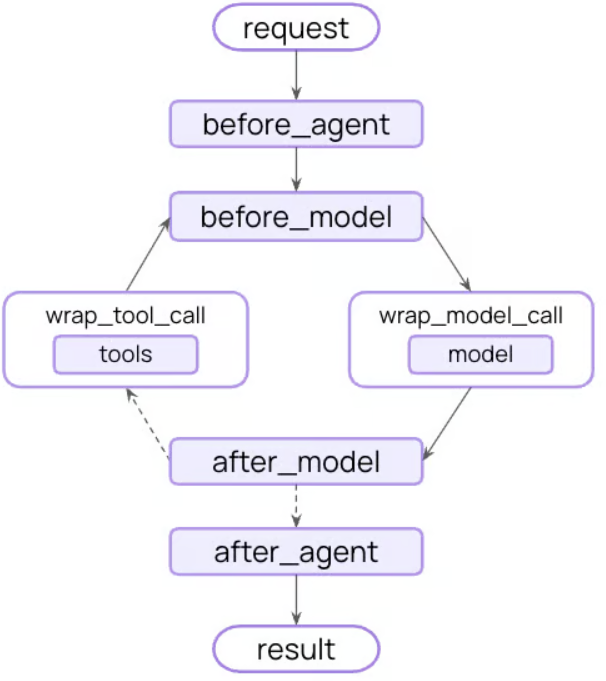

다음은 미들웨어를 통해 구현한 간단한 가드레일입니다. 해당 미들웨어는 delete_file 도구가 실행되는 것을 차단하며, 그 결과를 에이전트에게 반환합니다.

In [ ]:
from langchain.agents.middleware import AgentMiddleware

class SimpleGuardMiddleware(AgentMiddleware):
    """
    위험 도구(delete_file) 격발 전 가로채어 실행을 차단하고 경고를 반환하는
    로컬 Zero-Trust 하네스 미들웨어입니다.
    """
    def wrap_tool_call(self, request, handler):
        tool_name = request.tool_call.get("name", "")
        if tool_name == "delete_file":
            # 차단 및 ToolMessage 생성하여 반환 (handler를 실행하지 않음)
            return ToolMessage(
                content="Permission Denied: Execution of delete_file is restricted by local security policy.",
                tool_call_id=request.tool_call["id"],
                status="error"
            )
        return handler(request)

    async def awrap_tool_call(self, request, handler):
        tool_name = request.tool_call.get("name", "")
        if tool_name == "delete_file":
            return ToolMessage(
                content="Permission Denied: Execution of delete_file is restricted by local security policy.",
                tool_call_id=request.tool_call["id"],
                status="error"
            )
        return await handler(request)

guard = SimpleGuardMiddleware()

# 미들웨어를 장착한 에이전트 빌드
guarded_agent = create_agent(model=llm, tools=tools, middleware=[guard])
print("Guarded Agent built!")

In [ ]:
from app.utils.message_utils import normalize_content
# 파일 삭제 시도 테스트
delete_query = {"messages": [HumanMessage(content="임시 로그 파일 temp_logs.txt를 delete_file 도구로 완전히 삭제해 줘.")]}
guard_response = guarded_agent.invoke(delete_query)

print("Final Answer:\n", normalize_content(guard_response["messages"][-1].content))

In [ ]:
for m in guard_response["messages"]:
    m.pretty_print()

---
## 핵심 실습 4: AgentTracer 구축 및 시연

전 단계의 토큰 사용량과 지연 시간(latency)을 단계별로 실시간 추적하고 시각화하는 공통 인프라 `AgentTracer`를 적용합니다.

In [ ]:
from modules.common.agent_tracer import AgentTracer

# AgentTracer 인스턴스 생성 및 에이전트에 middleware로 주입
tracer = AgentTracer(verbose=True)
traced_agent = create_agent(model=llm, tools=tools, middleware=[tracer])

In [ ]:
# 에이전트 질문 기동
config = {"configurable": {"thread_id": "traced_session_01"}}
result = traced_agent.invoke(
    {"messages": [HumanMessage(content="paper.txt 파일을 열고 그 수식에 x=5를 대입해서 계산해줘.")]}, 
    config=config
)

In [ ]:
# 📊 Jupyter에 최적화된 다크 테마 실행 타임라인 출력
tracer.show_timeline()

In [ ]:
# 📊 도구 통계 요약표 출력
tracer.show_tool_summary()

---
## ★ 핵심 실습 5: 시나리오 기반 자동 평가

구축한 에이전트 하네스 인프라를 확장하여, 준비된 테스트 데이터셋(`tests/datasets/ch1_scenarios.json`)을 자동으로 구동하고 검증 리포트를 생성하는 `EvalRunner` 실습을 수행합니다.

In [ ]:
from modules.common.eval_runner import EvalRunner

# tracer와 평가 대상 에이전트를 결합하여 EvalRunner 생성
# 💡 2번째 보안 차단 시나리오(delete_file) 검증을 위해, 3번 실습에서 구현한 SimpleGuardMiddleware(guard)를 함께 장착해 줍니다.
eval_tracer = AgentTracer(verbose=False)
guard = SimpleGuardMiddleware()
eval_agent = create_agent(model=llm, tools=tools, middleware=[eval_tracer, guard])

# EvalRunner 인스턴스를 생성하고 시나리오를 구동한 후 요약 리포트를 출력합니다.
runner = EvalRunner(eval_agent, eval_tracer)
results = runner.run_scenarios("tests/datasets/ch1_scenarios.json")
runner.show_report(results)

In [ ]:
# 에이전트 루프 구조 시각화
from modules.common.viz import render_loop_architecture_svg
from IPython.display import display, HTML

display(HTML(render_loop_architecture_svg()))

---
## 📣 다음 교시 예고

1교시에서 성공적으로 다진 **`AgentTracer` 및 middleware 주입 패턴**은 차기 교시(2~4교시)에서 고도화된 프론티어 에이전트 기작(컨텍스트 압축, 자가 수정 Stop Hooks, Hermes 메모리 학습 루프)을 추적하고 모니터링하는 데 동일하게 상속되어 사용됩니다.